In [28]:
import mne
import csv
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import random
import math
import os.path as op
import seaborn as sns
import pandas as pd

In [29]:
def Behavioral_Data(n):
    stay_cue = []
    safe_risk = []
    no_ask = []
    safe_risk_0 = []
    behavior_data = []
    can_ask = []
    fname = 'E:/practice/behavioral/uncertainty_' + str(n) + '_2022.csv'
    with open(fname,'r') as f :
        for line in f.readlines():
            if line.split(',')[0]=='0' or line.split(',')[0]=='1':
                if int(line.split(',')[3])==0:
                    no_ask.append(0)
                elif int(line.split(',')[3])==1 or int(line.split(',')[3])==2:
                    no_ask.append(1)
                else :
                    print('ERROR')
                stay_cue.append(int(line.split(',')[3]))
                safe_risk.append(int(float(line.split(',')[6])))
                safe_risk_0.append(int(line.split(',')[4]))
                if line.split(',')[1]==' ':
                    can_ask.append(0)
                else :
                    can_ask.append(1)
    behavior_data.append(stay_cue)
    behavior_data.append(safe_risk)
    behavior_data.append(safe_risk_0)
    behavior_data.append(no_ask)
    behavior_data.append(can_ask)
    return behavior_data

In [30]:
trials = 120

# subject = [1,5,6,7,8,9,11,12,14,15,16,18,19,21,24]
subject = [1,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
if_can_ask = []
first_choice = []
first_result = []
second_choice = []
second_result = []
agent = []
trial = []
for i in range(len(subject)):
    behavior_data = Behavioral_Data(subject[i])
    stay_cue = behavior_data[0]
    safe_risk = behavior_data[1]
    safe_risk_0 = behavior_data[2]
    no_ask = behavior_data[3]
    can_ask = behavior_data[4]
    # for j in range(len(stay_cue)):
    if_can_ask.append(can_ask)
    first_choice.append(no_ask)
    first_result.append(stay_cue)
    second_choice.append(safe_risk_0)
    second_result.append(safe_risk)
    agent.append(i)

In [31]:
num_cue = []
num_no = []
num_safe_0 = []
num_safe_1 = []
num_safe_2 = []
num_risk_0 = []
num_risk_1 = []
num_risk_2 = []
# subject = [1,5,6,7,8,9,11,12,14,15,16,18,19,21,24]
subject = [1,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25]
for i in range(len(subject)):
    n_cue = 0
    n_no = 0
    n_safe_0 = 0
    n_safe_1 = 0
    n_safe_2 = 0
    n_risk_0 = 0
    n_risk_1 = 0
    n_risk_2 = 0
    for j in range(trials):
        if if_can_ask[i][j]==1:
            if first_choice[i][j]==1:
                n_cue+=1
            else:
                n_no+=1
        if first_result[i][j]==0:
            if second_choice[i][j]==0:
                n_safe_0+=1
            else:
                n_risk_0+=1
        elif first_result[i][j]==1:
            if second_choice[i][j]==0:
                n_safe_1+=1
            else:
                n_risk_1+=1
        elif first_result[i][j]==2:
            if second_choice[i][j]==0:
                n_safe_2+=1
            else:
                n_risk_2+=1
    num_cue.append(n_cue)
    num_no.append(n_no)
    num_safe_0.append(n_safe_0)
    num_safe_1.append(n_safe_1)
    num_safe_2.append(n_safe_2)
    num_risk_0.append(n_risk_0)
    num_risk_1.append(n_risk_1)
    num_risk_2.append(n_risk_2)
# data = {'n_cue':num_cue,'n_no':num_no,'n_safe_0':num_safe_0,'n_safe_1':num_safe_1,'n_safe_2':num_safe_2,'n_risk_0':num_risk_0,'n_risk_1':num_risk_1,'n_risk_2':num_risk_2}
# data = pd.DataFrame(data)

In [32]:
kind = []
condition = []
num = []
for i in range(len(subject)):
    kind.append('no_cue')
    kind.append('no_cue')
    condition.append('0')
    condition.append('1')
    num.append(num_no[i])
    num.append(num_cue[i])
    
    kind.append('condition0')
    kind.append('condition0')
    condition.append('0')
    condition.append('1')
    num.append(num_safe_0[i])
    num.append(num_risk_0[i])
    
    kind.append('condition1')
    kind.append('condition1')
    condition.append('0')
    condition.append('1')
    num.append(num_safe_1[i])
    num.append(num_risk_1[i])
    
    kind.append('condition2')
    kind.append('condition2')
    condition.append('0')
    condition.append('1')
    num.append(num_safe_2[i])
    num.append(num_risk_2[i])
data = {'kind':kind,'condition':condition,'num':num}
data = pd.DataFrame(data)

In [26]:
data.head(5)

,kind,condition,num
0,no_cue,0,27
1,no_cue,1,58
2,condition0,0,7
3,condition0,1,55
4,condition1,0,4


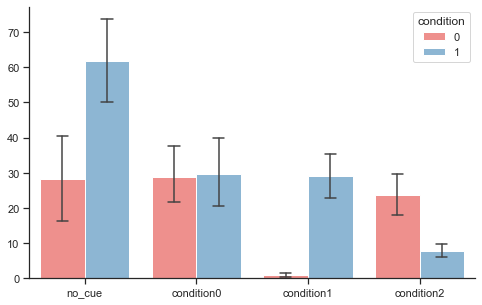

In [35]:
flatui = [(254/255,129/255,125/255),(129/255,184/255,223/255)]
# flatui = [(189/255, 107/255, 115/255),(69/255, 123/255, 157/255)]
# flatui = [(188/255,117/255,125/255),(102/255,149/255,177/255)]

sns.set_palette(flatui)
# plt.scatter(np.zeros((46)),Exploration_0,s=15,color=(102/255,149/255,177/255))
# plt.scatter(np.ones((46)),Exploration_1,s=15,color=(188/255,117/255,125/255))
plt.figure(figsize=(8,5))
# sns.barplot(x=kind,y=num,hue='condition',data=data,palette="Blues_d")

# sns.barplot(x=kind,y=num,hue='condition',data=data,capsize=0.1,errwidth=1.5,edgecolor='black',facecolor='white',linewidth=1)
sns.barplot(x=kind,y=num,hue='condition',data=data,capsize=0.1,errwidth=1.5,)

sns.set(style='ticks')
sns.despine()
plt.show()

In [36]:
trial = []
reward = []
for i in range(len(subject)):
    for j in range(40):
        trial.append(3*j+3)
        reward.append((second_result[i][j]+second_result[i][j+1]+second_result[i][j+2])/3)
data_reward = {'trial':trial,'reward':reward}
data_reward = pd.DataFrame(data_reward)

c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


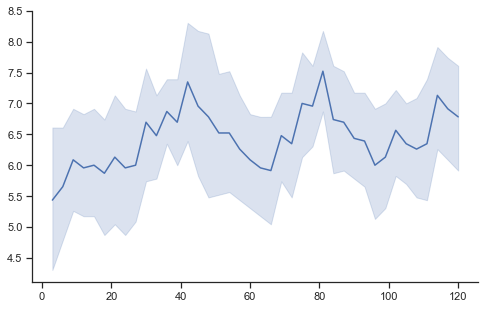

In [37]:
plt.figure(figsize=(8,5))
sns.lineplot(trial,reward,data=data_reward)
sns.set(style='ticks')
sns.despine()
plt.show()

In [ ]:
# model validation: active inference vs model free RL
# average rewards / trials
# number of cue/no options, safe/risk option under context1/context2/don't konw context

In [38]:
rl = [-177.37169823515313,-132.97212417904288,-281.01222668144777,-170.25434194850936,-97.28764702058187,-203.94699859281928,-144.837818211764,-137.41334621111807,-80.30655769709303,-90.28487770987635,-371.54584831186094,-319.0946651402149,-114.72398626699744,-150.88571595337157,-353.9919622008676,-109.14518980380238,-85.03404730120563,-275.1848392633867,-143.38374971462898,-142.11135047065082,-341.73514636330736,-101.38838056871852]

In [39]:
rl_llh = [-177.37169823515313,-132.97212417904288,-281.01222668144777,-170.25434194850936,-97.28764702058187,-203.94699859281928,-144.837818211764,-137.41334621111807,-80.30655769709303,-90.28487770987635,-371.54584831186094,-319.0946651402149,-114.72398626699744,-150.88571595337157,-353.9919622008676,-109.14518980380238,-85.03404730120563,-275.1848392633867,-143.38374971462898,-142.11135047065082,-341.73514636330736,-101.38838056871852]
ai_llh = [-112.89666722166731,-166.53698308724572,-186.18110323047839,-102.52156003332605,-154.92165905316048,-89.06676484580616,-113.01228137218472,-313.60325339613394,-68.857544911172,-149.03462287855714,-157.58708685907496,-153.1573507681957,-91.65348448424632,-133.8204511063077,-227.4787930228136,-53.62454300016182,-147.3226263960797,-313.11086906770595,-63.81761163265339,-161.57372796810137,-407.3455669264048,-131.8004215900288]
agent = []
llh = []
for i in range(len(rl_llh)):
    agent.append('model-free-RL')
    llh.append(rl_llh[i]/240)
    agent.append('active-inference')
    llh.append(ai_llh[i]/240)
data_llh = {'agent':agent,'log-likelihood':llh}
data_llh = pd.DataFrame(data_llh)

In [43]:
rl_llh = [-177.37169823515313,-132.97212417904288,-281.01222668144777,-170.25434194850936,-97.28764702058187,-203.94699859281928,-144.837818211764,-137.41334621111807,-80.30655769709303,-90.28487770987635,-371.54584831186094,-319.0946651402149,-114.72398626699744,-150.88571595337157,-353.9919622008676,-109.14518980380238,-85.03404730120563,-275.1848392633867,-143.38374971462898,-142.11135047065082,-341.73514636330736,-101.38838056871852]
ai_llh = [-112.89666722166731,-166.53698308724572,-186.18110323047839,-102.52156003332605,-154.92165905316048,-89.06676484580616,-113.01228137218472,-313.60325339613394,-68.857544911172,-149.03462287855714,-157.58708685907496,-153.1573507681957,-91.65348448424632,-133.8204511063077,-227.4787930228136,-53.62454300016182,-147.3226263960797,-313.11086906770595,-63.81761163265339,-161.57372796810137,-407.3455669264048,-131.8004215900288]
agent = []
llh = []
for i in range(len(rl_llh)):
    agent.append('model-free-RL')
    llh.append(-rl_llh[i]/240)
    agent.append('active-inference')
    llh.append(-ai_llh[i]/240)
data_llh = {'agent':agent,'log-likelihood':llh}
data_llh = pd.DataFrame(data_llh)

c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


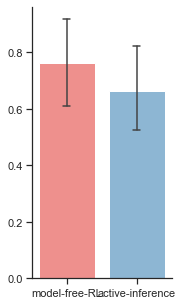

In [44]:
flatui = [(254/255,129/255,125/255),(129/255,184/255,223/255)]
# flatui = [(189/255, 107/255, 115/255),(69/255, 123/255, 157/255)]
# flatui = [(188/255,117/255,125/255),(102/255,149/255,177/255)]
sns.set_palette(flatui)
plt.figure(figsize=(2.5,5))
sns.barplot(agent,llh,data=data_llh,capsize=0.1,errwidth=1.5,)
sns.set(style='ticks')
sns.despine()
plt.show()